# Mechanistic analysis of LoRA and DoRA weight updates

For a PyTorch linear weight, $W \in \mathbb{R}^{out \times in}$, each row is decomposed into magnitude and direction:

$$m_i = \lVert W_{i,:} \rVert_2, \qquad d_{i,:} = W_{i,:}/m_i.$$

The primary mechanistic quantities are:

$$\Delta D = \operatorname{mean}_i\left[1-\cos(d_i,d_{0,i})\right],$$

$$\Delta M_{paper} = \operatorname{mean}_i |m_i-m_{0,i}|,$$

$$\Delta M_{rel} = \frac{\lVert m-m_0\rVert_2}{\lVert m_0\rVert_2}.$$

LoRA/QLoRA uses $W' = W_0+sBA$. DoRA/QDoRA rescales each row
of $W_0+sBA$ to the learned magnitude vector. The notebook reports both the
relative low-rank coefficient update $\lVert sBA\rVert_F/\lVert W_0\rVert_F$
and the relative effective update $\lVert W'-W_0\rVert_F/\lVert W_0\rVert_F$.


## 1. Setup and analysis configuration


In [3]:
import copy
import json
import math
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from safetensors.torch import safe_open

# Locate the project training utilities used to load the base model.
for candidate in (Path("simple").resolve(), Path("..").resolve()):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from train import finalize_config, load_model_and_tokenizer, read_yaml


ROOT = Path("/teamspace/lightning_storage/models")

RUNS = {
    "lora-v2":            {"run_dir": ROOT / "lora-v2",            "method": "LoRA",  "seed": 42},
    "lora-match-seed42":  {"run_dir": ROOT / "lora-match-seed42",  "method": "LoRA",  "seed": 42},
    "lora-match-seed43":  {"run_dir": ROOT / "lora-match-seed43-v2",  "method": "LoRA",  "seed": 43},
    "dora-seed42":        {"run_dir": ROOT / "dora",               "method": "DoRA",  "seed": 42},
    "dora-seed43":        {"run_dir": ROOT / "dora-seed43",        "method": "DoRA",  "seed": 43},
    # "qdora-seed42":       {"run_dir": ROOT / "qdora",              "method": "QDoRA", "seed": 42},
    # "qdora-seed43":       {"run_dir": ROOT / "qdora-seed43",       "method": "QDoRA", "seed": 43},
    "qdora-seed42-fp32": {'run_dir': ROOT / 'qdora-seed42-fp32', 'method':'QDoRA-fp32', "seed": 42},
    "qdora-seed43-fp32": {'run_dir': ROOT / 'qdora-seed43-fp32', 'method':'QDoRA-fp32', "seed": 43},    
    "qlora-seed42":       {"run_dir": ROOT / "qlora",              "method": "QLoRA", "seed": 42},
    "qlora-seed43":       {"run_dir": ROOT / "qlora-seed43",       "method": "QLoRA", "seed": 43},
    
    # "diagnostic-bf16": {
    #     "run_dir": Path("/teamspace") / "jobs" / "train-qdora-seed43-diagnostic-bf16" / "artifacts" / "dora-case-studies" / "outputs" / "meta-llama-3-8b-qdora-43-bf16",
    #     "method": "QDoRA bf16",
    #     "seed": 43,
    # },
    # "diagnostic-fp32": {
    #     "run_dir": Path("/teamspace") / "jobs" / "train-qdora-seed43-diagnostic-fp32" / "artifacts" / "dora-case-studies" / "outputs" / "meta-llama-3-8b-qdora-43-fp32",
    #     "method": "QDoRA fp32",
    #     "seed": 43,
    # }
    
}

PAPER_TARGET_MODULES = ["q_proj", "v_proj"]
EXTENDED_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "up_proj", "down_proj", "gate_proj",
]
TARGET_MODULES = list(dict.fromkeys(PAPER_TARGET_MODULES + EXTENDED_TARGET_MODULES))
LAYERS = list(range(6))
CHECKPOINT_FRACTIONS = (0.25, 0.50, 0.75, 1.00)

PAPER_M_METRIC = "delta_magnitude_paper"
NORMALIZED_M_METRIC = "delta_magnitude_rel"
EPS = 1e-12
COMPUTE_QUANTIZATION_EFFECTS = True

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ORDER = list(RUNS)


def display_name(run_id):
    info = RUNS[run_id]
    seed = f"seed {info['seed']}" if info["seed"] is not None else run_id
    return f"{info['method']} ({seed})"


## 2. Snapshot selection, weight loading, and reconstruction



In [4]:
def snapshot_metadata(snapshot_dir):
    path = Path(snapshot_dir) / "snapshot_metadata.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}


def snapshot_step(snapshot_dir):
    metadata = snapshot_metadata(snapshot_dir)
    if metadata.get("step") is not None:
        return int(metadata["step"])
    match = re.search(r"step_(\d+)", Path(snapshot_dir).name)
    return int(match.group(1)) if match else 0


def snapshot_label(snapshot_dir):
    return snapshot_metadata(snapshot_dir).get("label", Path(snapshot_dir).name)


def discover_snapshots(run_dir, fractions=CHECKPOINT_FRACTIONS):
    snapshot_root = Path(run_dir) / "analysis_snapshots"
    snapshots = sorted(
        (
            path for path in snapshot_root.iterdir()
            if path.is_dir() and (path / "adapter_model.safetensors").exists()
        ),
        key=lambda path: (snapshot_step(path), path.name),
    )

    explicit_final = [
        path for path in snapshots if str(snapshot_label(path)).lower() == "final"
    ]
    final_snapshot = max(explicit_final or snapshots, key=snapshot_step)
    final_step = snapshot_step(final_snapshot)

    selected = []
    for fraction in fractions:
        if np.isclose(fraction, 1.0):
            selected.append(final_snapshot)
            continue

        expected_label = f"fraction_{fraction:g}"
        labelled = [
            path for path in snapshots if str(snapshot_label(path)) == expected_label
        ]
        candidates = labelled or [path for path in snapshots if path != final_snapshot]
        target_step = fraction * final_step
        selected.append(
            min(candidates, key=lambda path: abs(snapshot_step(path) - target_step))
        )
    return selected


def base_weight_spec(run_dir):
    config = finalize_config(read_yaml(Path(run_dir) / "resolved_config.yaml"))
    model = config.get("model", {})
    quantization = config.get("quantization", {}) or {}
    return {
        "model_id": model.get("id"),
        "revision": model.get("revision", "main"),
        "dtype": str(model.get("dtype", model.get("torch_dtype"))),
        "quantized": bool(quantization.get("enabled", False)),
        "quant_type": quantization.get("bnb_4bit_quant_type", quantization.get("quant_type")),
        "double_quant": quantization.get("bnb_4bit_use_double_quant", quantization.get("double_quant")),
        "compute_dtype": str(
            quantization.get("bnb_4bit_compute_dtype", quantization.get("compute_dtype"))
        ),
    }


def projection_module(model, layer, target_module):
    block = model.model.layers[layer]
    if target_module in {"q_proj", "k_proj", "v_proj", "o_proj"}:
        return getattr(block.self_attn, target_module)
    return getattr(block.mlp, target_module)


def extract_weight(module):
    weight = module.weight
    if weight.device.type == "meta" or getattr(weight, "is_meta", False):
        raise RuntimeError("The requested base weight is offloaded to the meta device.")

    quantization_state = getattr(weight, "quant_state", None)
    if quantization_state is not None:
        import bitsandbytes.functional as bnb_f

        weight = bnb_f.dequantize_4bit(weight.data, quantization_state)
    return weight.detach().to(torch.float32).cpu()


BASE_WEIGHT_CACHE = {}


def base_cache_key(specification, force_dense):
    if force_dense or not specification["quantized"]:
        return specification["model_id"], specification["revision"], "dense"
    return (
        specification["model_id"], specification["revision"], "nf4",
        specification["quant_type"], specification["double_quant"],
        specification["compute_dtype"],
    )


def load_base_projection_weights(run_dir, force_dense=False):
    specification = base_weight_spec(run_dir)
    key = base_cache_key(specification, force_dense)
    if key in BASE_WEIGHT_CACHE:
        return BASE_WEIGHT_CACHE[key]

    config = copy.deepcopy(finalize_config(read_yaml(Path(run_dir) / "resolved_config.yaml")))
    if force_dense:
        config.setdefault("quantization", {})["enabled"] = False

    model, _ = load_model_and_tokenizer(config)
    model.eval()
    weights = {
        module: {
            layer: extract_weight(projection_module(model, layer, module))
            for layer in LAYERS
        }
        for module in TARGET_MODULES
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    result = weights, specification
    BASE_WEIGHT_CACHE[key] = result
    return result


def adapter_key_prefix(layer, target_module):
    if target_module in {"q_proj", "k_proj", "v_proj", "o_proj"}:
        block = f"self_attn.{target_module}"
    else:
        block = f"mlp.{target_module}"
    return f"base_model.model.model.layers.{layer}.{block}"


def lora_scaling(adapter_config):
    rank = float(adapter_config["r"])
    alpha = float(adapter_config["lora_alpha"])
    return alpha / math.sqrt(rank) if adapter_config.get("use_rslora", False) else alpha / rank


def configured_target_modules(adapter_config):
    # Restrict analysis to projection families that this adapter trained.
    configured = adapter_config.get("target_modules", TARGET_MODULES)
    if isinstance(configured, str):
        return [
            module for module in TARGET_MODULES
            if re.search(configured, module) is not None
        ]
    configured = set(configured)
    return [module for module in TARGET_MODULES if module in configured]


def load_adapter_components(snapshot_dir, layer, target_module, adapter_config):
    prefix = adapter_key_prefix(layer, target_module)
    path = Path(snapshot_dir) / "adapter_model.safetensors"

    with safe_open(path, framework="pt", device="cpu") as tensors:
        keys = set(tensors.keys())
        lora_a = tensors.get_tensor(f"{prefix}.lora_A.weight").float()
        lora_b = tensors.get_tensor(f"{prefix}.lora_B.weight").float()
        magnitude_key = next(
            (key for key in keys if key.startswith(f"{prefix}.lora_magnitude_vector")),
            None,
        )
        magnitude = (
            tensors.get_tensor(magnitude_key).float().reshape(-1)
            if adapter_config.get("use_dora", False)
            else None
        )
    return lora_a, lora_b, magnitude


def reconstruct_effective_weight(base_weight, lora_a, lora_b, scaling, magnitude=None):
    coefficient_update = float(scaling) * (lora_b.float() @ lora_a.float())
    directional_weight = base_weight.float() + coefficient_update
    if magnitude is None:
        return directional_weight, coefficient_update

    row_norm = torch.linalg.vector_norm(directional_weight, dim=1).clamp_min(EPS)
    dora_factor = magnitude.float().reshape(-1, 1) / row_norm.reshape(-1, 1)
    return dora_factor * directional_weight, coefficient_update


## 3. Mechanistic metrics by run, checkpoint, layer, and module

`mech_layer_metrics.csv` is the canonical analysis dataset. It contains one row per physical run × checkpoint × layer × target module, avoiding separate tables that repeat the same values.


In [5]:
def decompose_weight(weight):
    weight = weight.float()
    magnitude = torch.linalg.vector_norm(weight, dim=1)
    direction = weight / magnitude.clamp_min(EPS).unsqueeze(1)
    return magnitude, direction


def delta_direction(current_direction, reference_direction):
    cosine = F.cosine_similarity(
        current_direction.float(), reference_direction.float(), dim=1, eps=EPS
    )
    return float((1.0 - cosine.clamp(-1.0, 1.0)).mean())


def magnitude_metrics(current_magnitude, reference_magnitude):
    difference = current_magnitude.float() - reference_magnitude.float()
    return {
        "delta_magnitude_paper": float(difference.abs().mean()),
        "delta_magnitude_rel": float(
            torch.linalg.vector_norm(difference)
            / torch.linalg.vector_norm(reference_magnitude.float()).clamp_min(EPS)
        ),
    }


def compute_layer_metrics(base_weight, snapshot_dir, layer, target_module,
                          adapter_config, dense_base_weight=None):
    lora_a, lora_b, magnitude = load_adapter_components(
        snapshot_dir, layer, target_module, adapter_config
    )
    effective_weight, coefficient_update = reconstruct_effective_weight(
        base_weight, lora_a, lora_b, lora_scaling(adapter_config), magnitude
    )

    base_magnitude, base_direction = decompose_weight(base_weight)
    current_magnitude, current_direction = decompose_weight(effective_weight)
    denominator = torch.linalg.norm(base_weight).clamp_min(EPS)

    row = {
        "snapshot": Path(snapshot_dir).name,
        "step": snapshot_step(snapshot_dir),
        "layer": layer,
        "target_module": target_module,
        "delta_direction": delta_direction(current_direction, base_direction),
        "coefficient_update_rel": float(torch.linalg.norm(coefficient_update) / denominator),
        "effective_weight_update_rel": float(
            torch.linalg.norm(effective_weight - base_weight) / denominator
        ),
    }
    row.update(magnitude_metrics(current_magnitude, base_magnitude))

    if dense_base_weight is not None:
        dense_magnitude, dense_direction = decompose_weight(dense_base_weight)
        row["quant_delta_direction"] = delta_direction(base_direction, dense_direction)
        row["total_delta_direction"] = delta_direction(current_direction, dense_direction)
        row.update({
            f"quant_{key}": value
            for key, value in magnitude_metrics(base_magnitude, dense_magnitude).items()
        })
        row.update({
            f"total_{key}": value
            for key, value in magnitude_metrics(current_magnitude, dense_magnitude).items()
        })
    return row


rows = []
for run_id, run_info in RUNS.items():
    run_dir = run_info["run_dir"]
    snapshots = discover_snapshots(run_dir)
    base_weights, base_specification = load_base_projection_weights(run_dir)

    dense_base_weights = None
    if base_specification["quantized"] and COMPUTE_QUANTIZATION_EFFECTS:
        dense_base_weights, _ = load_base_projection_weights(run_dir, force_dense=True)

    for checkpoint_fraction, snapshot_dir in zip(CHECKPOINT_FRACTIONS, snapshots):
        adapter_config = json.loads(
            (snapshot_dir / "adapter_config.json").read_text(encoding="utf-8")
        )
        snapshot_target_modules = configured_target_modules(adapter_config)
        for target_module in snapshot_target_modules:
            for layer in LAYERS:
                row = compute_layer_metrics(
                    base_weights[target_module][layer],
                    snapshot_dir,
                    layer,
                    target_module,
                    adapter_config,
                    dense_base_weight=(
                        dense_base_weights[target_module][layer]
                        if dense_base_weights is not None else None
                    ),
                )
                row.update({
                    "run_id": run_id,
                    "run": display_name(run_id),
                    "method": run_info["method"],
                    "seed": run_info["seed"],
                    "checkpoint_fraction": checkpoint_fraction,
                    "quantized_base": base_specification["quantized"],
                })
                rows.append(row)

weight_df = pd.DataFrame(rows).sort_values(
    ["run_id", "checkpoint_fraction", "target_module", "layer"]
).reset_index(drop=True)

layer_metric_columns = [
    "run_id", "run", "method", "seed", "snapshot", "step",
    "checkpoint_fraction", "layer", "target_module", "quantized_base",
    "delta_direction", "delta_magnitude_paper", "delta_magnitude_rel",
    "coefficient_update_rel", "effective_weight_update_rel",
] + [
    column for column in weight_df.columns
    if column.startswith("quant_") or column.startswith("total_")
]
layer_metric_columns = list(dict.fromkeys(layer_metric_columns))
weight_df[layer_metric_columns].to_csv(
    OUTPUT_DIR / "mech_layer_metrics.csv", index=False
)

print(f"Mechanistic dataset: {len(weight_df):,} rows")
print(f"Exported: {OUTPUT_DIR / 'mech_layer_metrics.csv'}")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[pad_token] WARNING: no distinct pad token found; falling back to pad_token = eos_token. Verify your data collator masks padding by POSITION (TRL's SFT collator does) so the real trailing EOS is still trained. If you use the transformers DataCollatorForLanguageModeling, the real EOS would be masked to -100 and the model would not learn to stop.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[pad_token] WARNING: no distinct pad token found; falling back to pad_token = eos_token. Verify your data collator masks padding by POSITION (TRL's SFT collator does) so the real trailing EOS is still trained. If you use the transformers DataCollatorForLanguageModeling, the real EOS would be masked to -100 and the model would not learn to stop.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Mechanistic dataset: 1,080 rows
Exported: outputs/mech_layer_metrics.csv


## 4. Regression coefficients

The regression table contains two complementary relationships:
- ΔM on ΔD across layer × checkpoint points for each run and module.
- Relative low-rank coefficient update on checkpoint fraction for each
  run, module, and layer.

Q/V rows include both the paper and normalized ΔM definitions. Extended
modules use the normalized definition for cross-scale comparison.


In [6]:
def fit_relation(frame, predictor, outcome):
    clean = frame[[predictor, outcome]].dropna()
    x = clean[predictor].to_numpy(dtype=float)
    y = clean[outcome].to_numpy(dtype=float)
    if len(x) < 2 or np.allclose(x, x[0]):
        return np.nan, np.nan, np.nan, np.nan, len(x)

    slope, intercept = np.polyfit(x, y, 1)
    correlation = np.nan if np.allclose(y, y[0]) else np.corrcoef(x, y)[0, 1]
    r_squared = correlation ** 2 if np.isfinite(correlation) else np.nan
    return slope, intercept, correlation, r_squared, len(x)


regression_rows = []
for (run_id, run_name, method, seed, module), subset in weight_df.groupby(
    ["run_id", "run", "method", "seed", "target_module"], dropna=False
):
    metrics = (
        [PAPER_M_METRIC, NORMALIZED_M_METRIC]
        if module in PAPER_TARGET_MODULES
        else [NORMALIZED_M_METRIC]
    )
    for metric in metrics:
        slope, intercept, correlation, r_squared, n_points = fit_relation(
            subset, "delta_direction", metric
        )
        regression_rows.append({
            "relationship": "delta_m_vs_delta_d",
            "run_id": run_id,
            "run": run_name,
            "method": method,
            "seed": seed,
            "target_module": module,
            "layer": np.nan,
            "predictor": "delta_direction",
            "outcome": metric,
            "slope": slope,
            "intercept": intercept,
            "correlation": correlation,
            "r_squared": r_squared,
            "n_points": n_points,
        })

    for layer, layer_subset in subset.groupby("layer"):
        slope, intercept, correlation, r_squared, n_points = fit_relation(
            layer_subset, "checkpoint_fraction", "coefficient_update_rel"
        )
        regression_rows.append({
            "relationship": "coefficient_update_vs_checkpoint",
            "run_id": run_id,
            "run": run_name,
            "method": method,
            "seed": seed,
            "target_module": module,
            "layer": layer,
            "predictor": "checkpoint_fraction",
            "outcome": "coefficient_update_rel",
            "slope": slope,
            "intercept": intercept,
            "correlation": correlation,
            "r_squared": r_squared,
            "n_points": n_points,
        })

regression_df = pd.DataFrame(regression_rows)
regression_df.to_csv(OUTPUT_DIR / "mech_regression_results.csv", index=False)

primary_regression = regression_df[
    (regression_df["relationship"] == "delta_m_vs_delta_d")
    & (regression_df["target_module"].isin(PAPER_TARGET_MODULES))
    & (regression_df["outcome"] == PAPER_M_METRIC)
][[
    "run", "target_module", "slope", "intercept",
    "correlation", "r_squared", "n_points",
]]
display(primary_regression.round(5))
print(f"Exported: {OUTPUT_DIR / 'mech_regression_results.csv'}")


,run,target_module,slope,intercept,correlation,r_squared,n_points
14,DoRA (seed 42),q_proj,0.27119,0.00549,0.74484,0.55479,24
29,DoRA (seed 42),v_proj,0.12257,0.00569,0.68974,0.47573,24
51,DoRA (seed 43),q_proj,0.22712,0.00571,0.67521,0.45592,24
66,DoRA (seed 43),v_proj,0.12211,0.00566,0.68418,0.46810,24
88,LoRA (seed 42),q_proj,0.78513,0.00025,0.99407,0.98817,24
103,LoRA (seed 42),v_proj,0.36265,0.00124,0.95256,0.90736,24
125,LoRA (seed 43),q_proj,0.75710,0.00043,0.99299,0.98603,24
140,LoRA (seed 43),v_proj,0.36314,0.00126,0.95594,0.91382,24
162,LoRA (seed 42),q_proj,1.11566,-0.00634,0.99299,0.98603,24
177,LoRA (seed 42),v_proj,0.37031,0.01759,0.93754,0.87898,24


Exported: outputs/mech_regression_results.csv


## 5. Paper-style ΔM–ΔD relationship


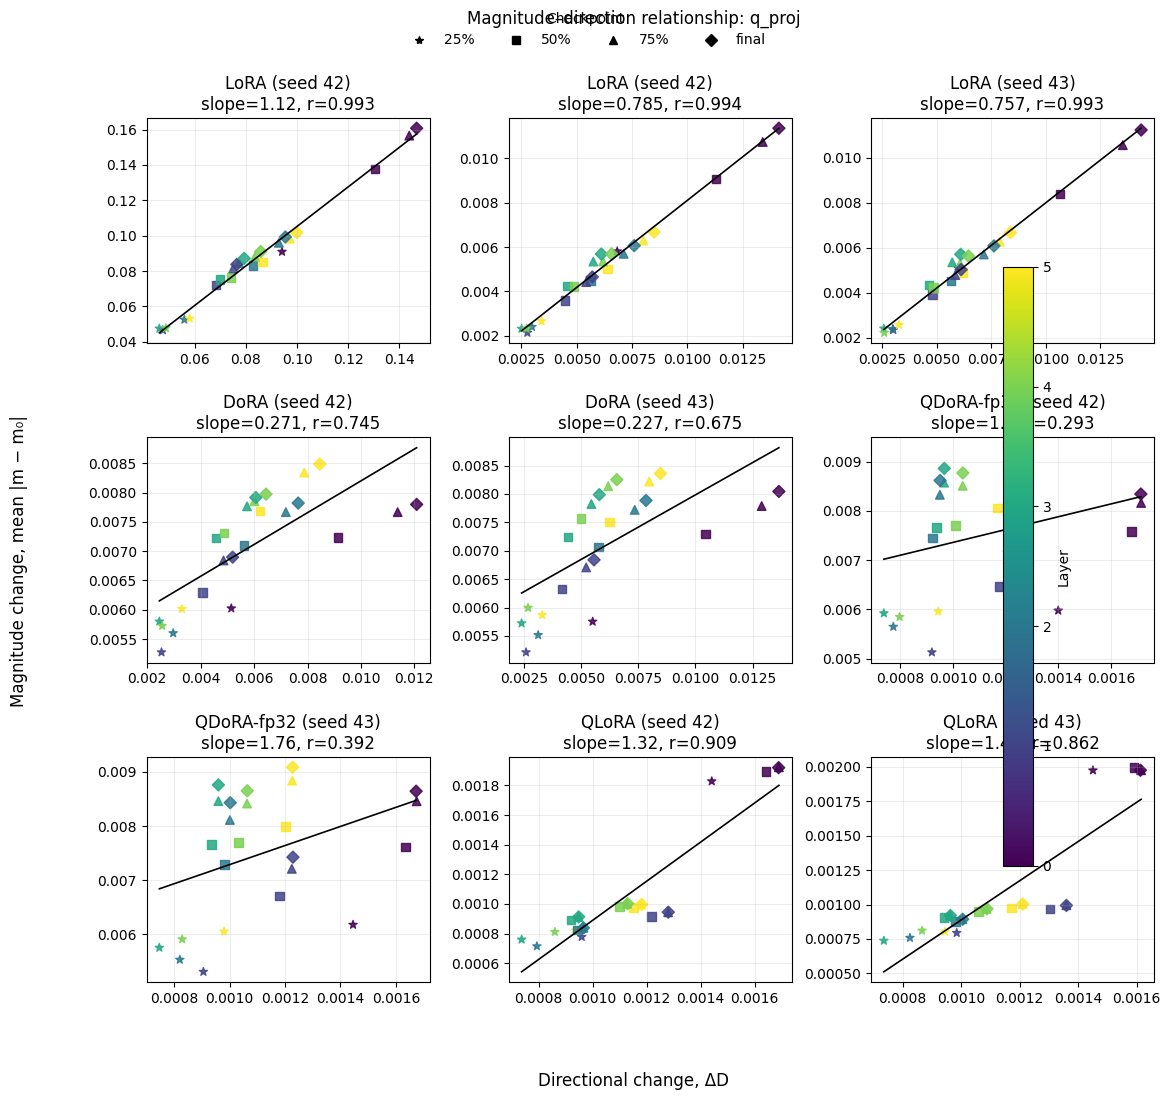

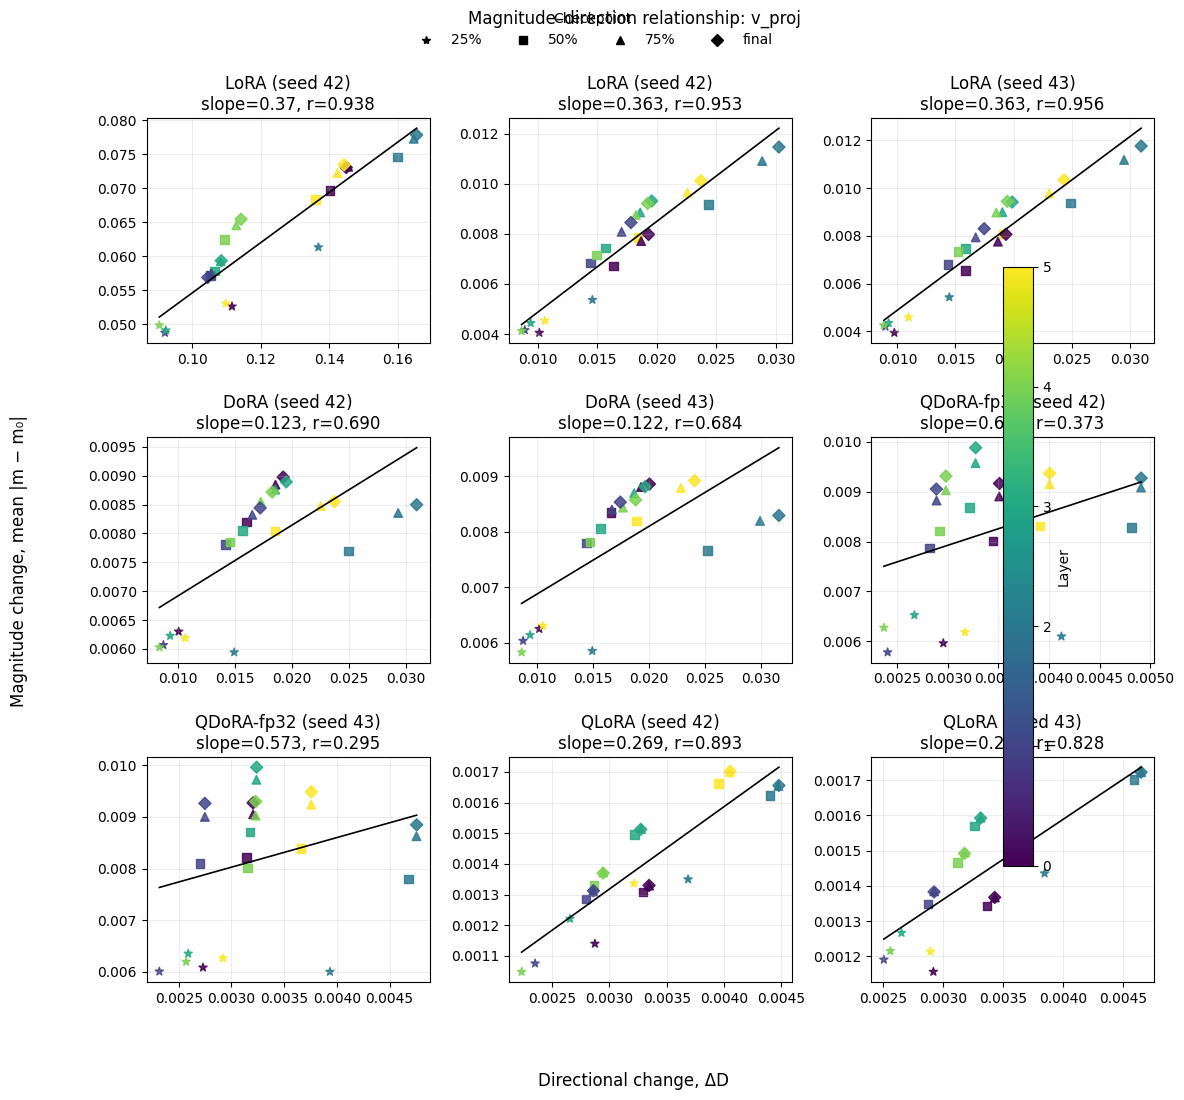

[PosixPath('outputs/mech_delta_m_vs_delta_d_q_proj.pdf'),
 PosixPath('outputs/mech_delta_m_vs_delta_d_v_proj.pdf')]

In [7]:
CHECKPOINT_MARKERS = {0.25: "*", 0.50: "s", 0.75: "^", 1.00: "D"}
paper_df = weight_df[weight_df["target_module"].isin(PAPER_TARGET_MODULES)].copy()


def plot_delta_m_vs_delta_d(module):
    run_ids = [run_id for run_id in RUN_ORDER if run_id in set(paper_df["run_id"])]
    ncols = 3
    nrows = math.ceil(len(run_ids) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(13, 3.6 * nrows), squeeze=False,
        sharex=False, sharey=False,
    )
    color_norm = plt.Normalize(min(LAYERS), max(LAYERS))

    for axis, run_id in zip(axes.flat, run_ids):
        subset = paper_df[
            (paper_df["run_id"] == run_id)
            & (paper_df["target_module"] == module)
        ]
        for checkpoint, checkpoint_subset in subset.groupby("checkpoint_fraction"):
            axis.scatter(
                checkpoint_subset["delta_direction"],
                checkpoint_subset[PAPER_M_METRIC],
                c=checkpoint_subset["layer"],
                cmap="viridis",
                norm=color_norm,
                marker=CHECKPOINT_MARKERS[float(checkpoint)],
                s=38,
                alpha=0.85,
            )

        slope, intercept, correlation, _, _ = fit_relation(
            subset, "delta_direction", PAPER_M_METRIC
        )
        x_values = np.linspace(
            subset["delta_direction"].min(), subset["delta_direction"].max(), 100
        )
        axis.plot(x_values, slope * x_values + intercept, color="black", linewidth=1.2)
        axis.set_title(f"{display_name(run_id)}\nslope={slope:.3g}, r={correlation:.3f}")
        axis.grid(alpha=0.22)

    for axis in axes.flat[len(run_ids):]:
        axis.set_visible(False)

    marker_handles = [
        Line2D(
            [0], [0], color="black", marker=marker, linestyle="None",
            markersize=6, label=("final" if fraction == 1.0 else f"{fraction:.0%}"),
        )
        for fraction, marker in CHECKPOINT_MARKERS.items()
    ]
    fig.legend(handles=marker_handles, title="Checkpoint", loc="upper center",
               ncol=4, frameon=False)
    scalar_map = plt.cm.ScalarMappable(norm=color_norm, cmap="viridis")
    fig.colorbar(scalar_map, ax=axes.ravel().tolist(), label="Layer", shrink=0.72)
    fig.supxlabel("Directional change, ΔD")
    fig.supylabel("Magnitude change, mean |m − m₀|")
    fig.suptitle(f"Magnitude–direction relationship: {module}", y=1.01)
    fig.subplots_adjust(top=0.91, hspace=0.42, wspace=0.28)

    output_path = OUTPUT_DIR / f"mech_delta_m_vs_delta_d_{module}.pdf"
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return output_path


delta_direction_figures = [
    plot_delta_m_vs_delta_d(module) for module in PAPER_TARGET_MODULES
]
delta_direction_figures


## 6. ΔM through layers

Each panel preserves the physical run and shows how the paper ΔM metric changes from layer 0 through layer 5 at every selected checkpoint.


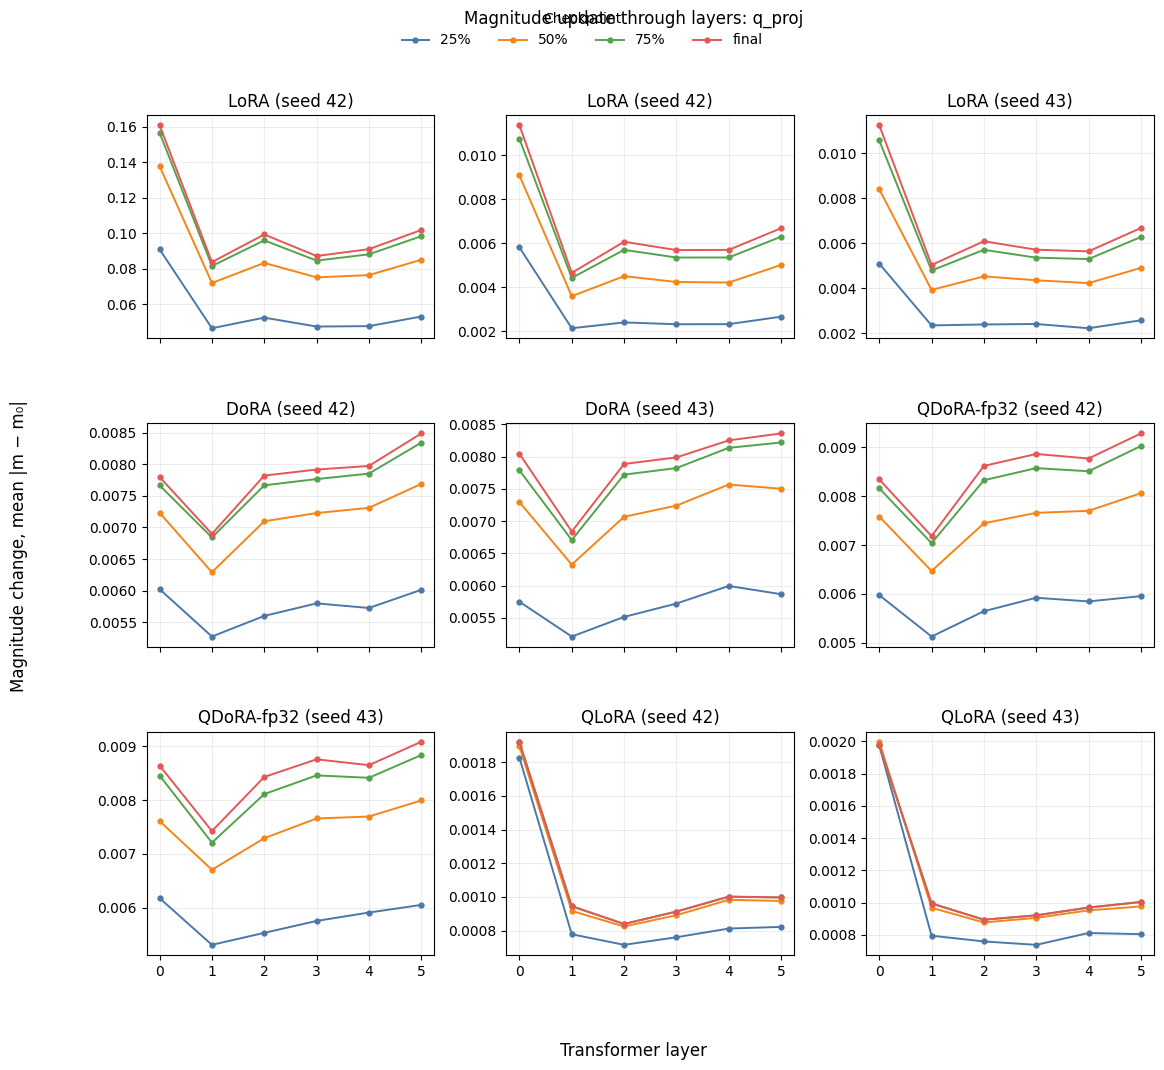

In [ ]:
CHECKPOINT_COLORS = {
    0.25: "#4C78A8", 0.50: "#F58518", 0.75: "#54A24B", 1.00: "#E45756"
}


def plot_delta_m_by_layer(module):
    run_ids = [run_id for run_id in RUN_ORDER if run_id in set(paper_df["run_id"])]
    ncols = 3
    nrows = math.ceil(len(run_ids) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(13, 3.5 * nrows), squeeze=False,
        sharex=True, sharey=False,
    )

    for axis, run_id in zip(axes.flat, run_ids):
        subset = paper_df[
            (paper_df["run_id"] == run_id)
            & (paper_df["target_module"] == module)
        ]
        for checkpoint, checkpoint_subset in subset.groupby("checkpoint_fraction"):
            checkpoint_subset = checkpoint_subset.sort_values("layer")
            axis.plot(
                checkpoint_subset["layer"],
                checkpoint_subset[PAPER_M_METRIC],
                color=CHECKPOINT_COLORS[float(checkpoint)],
                marker="o",
                linewidth=1.4,
                markersize=3.5,
                label=("final" if checkpoint == 1.0 else f"{checkpoint:.0%}"),
            )
        axis.set_title(display_name(run_id))
        axis.set_xticks(LAYERS)
        axis.grid(alpha=0.22)

    for axis in axes.flat[len(run_ids):]:
        axis.set_visible(False)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Checkpoint", loc="upper center",
               ncol=4, frameon=False)
    fig.supxlabel("Transformer layer")
    fig.supylabel("Magnitude change, mean |m − m₀|")
    fig.suptitle(f"Magnitude update through layers: {module}", y=1.01)
    fig.subplots_adjust(top=0.91, hspace=0.38, wspace=0.25)

    output_path = OUTPUT_DIR / f"mech_delta_m_by_layer_{module}.pdf"
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return output_path


layer_figures = [plot_delta_m_by_layer(module) for module in PAPER_TARGET_MODULES]
layer_figures


## 7. Low-rank coefficient-update slopes through layers

For each physical run, module, and layer, this view plots the slope of
$\lVert sBAVert_F/\lVert W_0Vert_F$ against checkpoint fraction. It
complements the ΔM–ΔD regression by showing where low-rank coefficient
updates accumulate most rapidly during training.


In [ ]:
coefficient_slopes = regression_df[
    (regression_df["relationship"] == "coefficient_update_vs_checkpoint")
    & (regression_df["target_module"].isin(PAPER_TARGET_MODULES))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=False)
colors = plt.cm.tab10(np.linspace(0, 1, len(RUN_ORDER)))
for axis, module in zip(axes, PAPER_TARGET_MODULES):
    module_data = coefficient_slopes[coefficient_slopes["target_module"] == module]
    for color, run_id in zip(colors, RUN_ORDER):
        subset = module_data[module_data["run_id"] == run_id].sort_values("layer")
        axis.plot(
            subset["layer"], subset["slope"], marker="o", markersize=3.5,
            linewidth=1.3, color=color, label=display_name(run_id),
        )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    axis.set_title(module)
    axis.set_xticks(LAYERS)
    axis.set_xlabel("Transformer layer")
    axis.grid(alpha=0.22)

axes[0].set_ylabel("Slope of relative coefficient update vs checkpoint fraction")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.suptitle("Low-rank coefficient-update slopes through layers")
fig.tight_layout()

coefficient_figure = OUTPUT_DIR / "mech_coefficient_update_slopes_by_layer.pdf"
fig.savefig(coefficient_figure, bbox_inches="tight")
plt.show()
plt.close(fig)
coefficient_figure


## 8. Quantization decomposition


In [ ]:
quantized_rows = weight_df[weight_df["quantized_base"]].copy()
quantization_columns = [
    "quant_delta_magnitude_paper", "delta_magnitude_paper",
    "total_delta_magnitude_paper", "quant_delta_direction",
    "delta_direction", "total_delta_direction",
]

quantization_summary = (
    quantized_rows
    .groupby(["run_id", "run", "method", "seed", "target_module"], dropna=False)
    [quantization_columns]
    .mean()
    .reset_index()
    .rename(columns={
        "quant_delta_magnitude_paper": "dM_quantization",
        "delta_magnitude_paper": "dM_adapter",
        "total_delta_magnitude_paper": "dM_total",
        "quant_delta_direction": "dD_quantization",
        "delta_direction": "dD_adapter",
        "total_delta_direction": "dD_total",
    })
)
quantization_summary["dM_quant_share"] = (
    quantization_summary["dM_quantization"]
    / quantization_summary["dM_total"].clip(lower=EPS)
)
quantization_summary["dD_quant_share"] = (
    quantization_summary["dD_quantization"]
    / quantization_summary["dD_total"].clip(lower=EPS)
)
quantization_summary.to_csv(
    OUTPUT_DIR / "mech_quantization_effects.csv", index=False
)

display(quantization_summary.round(5))
print(f"Exported: {OUTPUT_DIR / 'mech_quantization_effects.csv'}")


## 9. Layer-0 sensitivity

This supplementary table shows whether the primary ΔM–ΔD result is driven
by layer 0. It contains only Q/V projections and the paper ΔM definition.


In [ ]:
sensitivity_rows = []
for (run_id, run_name, method, seed, module), subset in paper_df.groupby(
    ["run_id", "run", "method", "seed", "target_module"], dropna=False
):
    slope_all, intercept_all, corr_all, r2_all, n_all = fit_relation(
        subset, "delta_direction", PAPER_M_METRIC
    )
    without_layer0 = subset[subset["layer"] != 0]
    slope_excl0, intercept_excl0, corr_excl0, r2_excl0, n_excl0 = fit_relation(
        without_layer0, "delta_direction", PAPER_M_METRIC
    )
    sensitivity_rows.append({
        "run_id": run_id,
        "run": run_name,
        "method": method,
        "seed": seed,
        "target_module": module,
        "slope_all_layers": slope_all,
        "correlation_all_layers": corr_all,
        "r_squared_all_layers": r2_all,
        "n_all_layers": n_all,
        "slope_excluding_layer0": slope_excl0,
        "correlation_excluding_layer0": corr_excl0,
        "r_squared_excluding_layer0": r2_excl0,
        "n_excluding_layer0": n_excl0,
    })

layer0_sensitivity = pd.DataFrame(sensitivity_rows)
layer0_sensitivity.to_csv(
    OUTPUT_DIR / "mech_layer0_sensitivity.csv", index=False
)
display(layer0_sensitivity.round(5))
print(f"Exported: {OUTPUT_DIR / 'mech_layer0_sensitivity.csv'}")


## 10. Export manifest

All retained tables and figures use the `mech_` prefix. The CSV files are
tidy, full-precision analysis tables; figures are vector PDFs suitable for
inclusion in a paper.


In [ ]:
exported_artifacts = sorted(
    path.name for path in OUTPUT_DIR.iterdir()
    if path.is_file() and path.name.startswith("mech_")
)
display(pd.DataFrame({"artifact": exported_artifacts}))
